<a href="https://colab.research.google.com/github/Rihabd06/portfolio-site/blob/main/Breast_Cancer_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

# Loading the file and preprocessing the data
data = pd.read_csv('breast-cancer.txt', na_values="?")
data = data.drop('id', axis=1)
data = data.dropna()
X = data.drop('class', axis=1).values
y = (data['class'] == 4).astype(int).values

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# One hidden layer with different number of nodes
for nodes in [5, 10, 20, 30]:
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(nodes, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, verbose=0)
    tr_acc = model.evaluate(X_train, y_train, verbose=0)[1]
    te_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f'Hidden nodes: {nodes}, Train acc: {tr_acc:.2f}, Test acc: {te_acc:.2f}')

Hidden nodes: 5, Train acc: 0.97, Test acc: 0.97
Hidden nodes: 10, Train acc: 0.97, Test acc: 0.96
Hidden nodes: 20, Train acc: 0.97, Test acc: 0.97
Hidden nodes: 30, Train acc: 0.98, Test acc: 0.96


In [ ]:
# Different number of layers
for n_layers in range(1, 11):
    model = models.Sequential([layers.Input(shape=(X_train.shape[1],))])
    for _ in range(n_layers):
        model.add(layers.Dense(10, activation='relu'))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, verbose=0)
    tr_acc = model.evaluate(X_train, y_train, verbose=0)[1]
    te_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f'Layers: {n_layers}, Train acc: {tr_acc:.2f}, Test acc: {te_acc:.2f}')


Layers: 1, Train acc: 0.97, Test acc: 0.97
Layers: 2, Train acc: 0.97, Test acc: 0.96
Layers: 3, Train acc: 0.97, Test acc: 0.99
Layers: 4, Train acc: 0.98, Test acc: 0.98
Layers: 5, Train acc: 0.98, Test acc: 0.98
Layers: 6, Train acc: 0.99, Test acc: 0.97
Layers: 7, Train acc: 0.98, Test acc: 0.97
Layers: 8, Train acc: 0.98, Test acc: 0.99
Layers: 9, Train acc: 0.98, Test acc: 0.96
Layers: 10, Train acc: 0.98, Test acc: 0.95


In [ ]:
# 4 hidden layers, dropout from 0% to 40%
for dropout in [0.0, 0.1, 0.2, 0.3, 0.4]:
    model = models.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))
    for _ in range(4):
        model.add(layers.Dense(10, activation='relu'))
        model.add(layers.Dropout(dropout))
    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, verbose=0)
    te_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f'Dropout: {dropout}, Test acc: {te_acc:.2f}')


Dropout: 0.0, Test acc: 0.99
Dropout: 0.1, Test acc: 0.98
Dropout: 0.2, Test acc: 0.99
Dropout: 0.3, Test acc: 0.97
Dropout: 0.4, Test acc: 0.97


In [ ]:
# 2 hidden layers, different activations
for act in ['relu', 'sigmoid', 'tanh']:
    model = models.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(10, activation=act),
        layers.Dense(10, activation=act),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X_train, y_train, epochs=50, verbose=0)
    te_acc = model.evaluate(X_test, y_test, verbose=0)[1]
    print(f'Activation: {act}, Test acc: {te_acc:.2f}')


Activation: relu, Test acc: 0.97
Activation: sigmoid, Test acc: 0.96
Activation: tanh, Test acc: 0.97


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


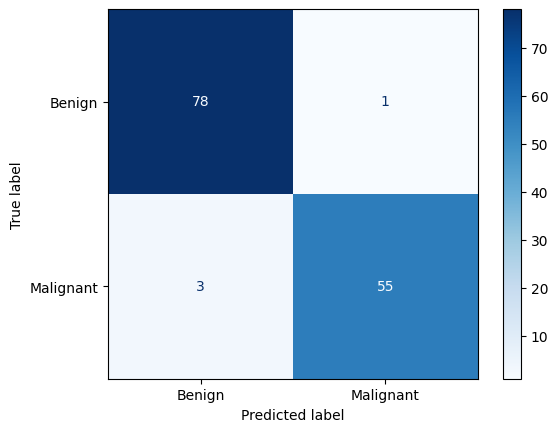

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Benign", "Malignant"])
disp.plot(cmap=plt.cm.Blues)
plt.show()
